# Topik: Implementasi Klasifikasi & Regresi Random Forest
### Menggunakan KNIME Analytics Platform
**Oleh: Fahdimas Akmal (Dimas)**

---

## 1. Landasan Teori: Random Forest
Dalam tugas ini, saya menerapkan algoritma **Random Forest**, yaitu metode *ensemble learning* yang membangun banyak pohon keputusan secara acak. Berbeda dengan metode tunggal, Random Forest menggunakan mekanisme *voting* untuk klasifikasi dan rata-rata untuk regresi, sehingga model yang dihasilkan lebih stabil dan akurat.

---

## 2. Tahapan Implementasi pada KNIME
Berikut adalah rincian tahapan yang saya lakukan dalam *workflow* ini:

1.  **Normalisasi:** Saya menyertakan tahap normalisasi untuk menyetarakan skala fitur numerik agar tidak ada fitur yang mendominasi perhitungan probabilitas secara tidak adil.
2.  **Table Partitioner (80:20):** Dataset saya bagi menjadi 80% untuk pelatihan model (*training*) dan 20% untuk pengujian (*testing*).
3.  **Model Training:** Saya melatih dua model sekaligus, yaitu klasifikasi untuk memprediksi "Play Tennis" dan regresi untuk memprediksi "Wind".
4.  **Evaluasi Multi-Scorer:** Saya menggunakan tiga jenis *scorer* untuk menguji performa model secara menyeluruh.

---

## 3. Dokumentasi Konfigurasi & Hasil (Screenshot)

### A. Konfigurasi Table Partitioner
Pada bagian ini, saya mengatur pembagian dataset menggunakan metode *Relative Size* sebesar 80% dengan strategi *Stratified Sampling* berdasarkan kolom target "Play Tennis".

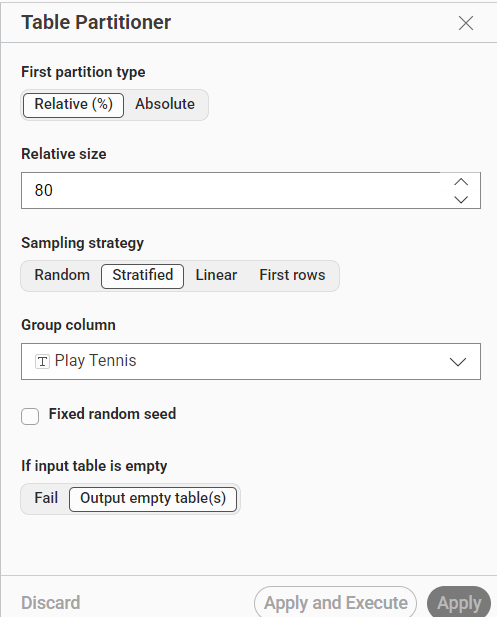

### B. Konfigurasi Random Forest Learner
Saya menentukan target kolom "Play Tennis" dan memasukkan fitur pendukung seperti *Day*, *Outlook*, dan *Temp* ke dalam atribut pelatihan. Kriteria pemisahan yang saya pilih adalah **Gini Index**.

![image_7223df.png - Screenshot RF Learner Classification Settings]

---

### C. Hasil Evaluasi Model (Scorer)

#### 1. Out-of-Bag (OOB) Scorer (Akurasi 36.36%)
Scorer pertama ini menunjukkan hasil prediksi internal model terhadap data yang tidak terambil saat proses *bootstrapping*.
* **Correct Classified:** 4
* **Wrong Classified:** 7
* **Accuracy:** **36.364%**
* **Error:** **63.636%**

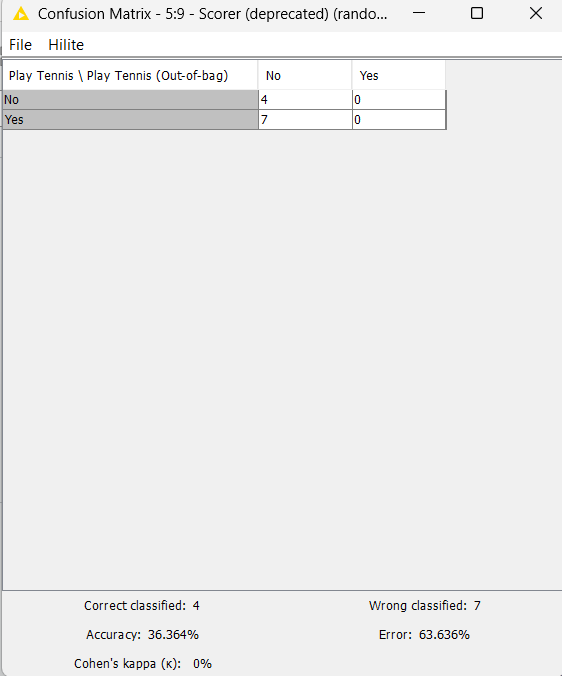

#### 2. Scorer Klasifikasi - Data Testing (Akurasi 66.67%)
Scorer kedua ini mengevaluasi performa model pada 20% data uji yang telah dipisahkan di awal.
* **Correct Classified:** 2
* **Wrong Classified:** 1
* **Accuracy:** **66.667%**

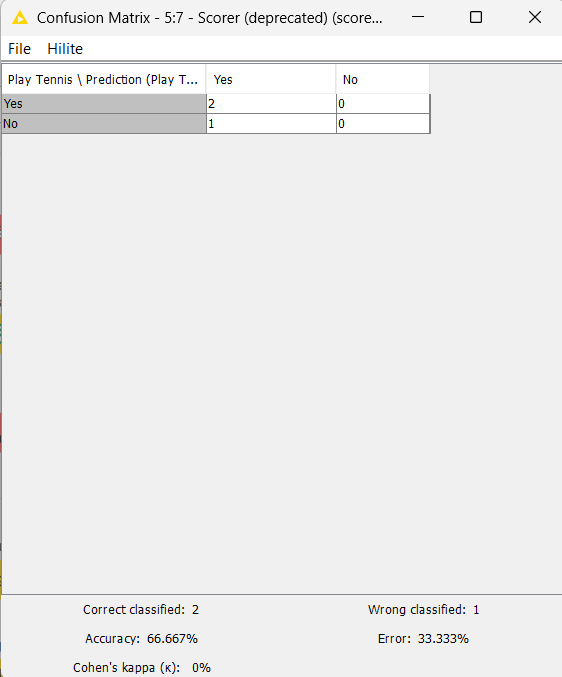

#### 3. Numeric Scorer - Regresi Wind
Scorer ketiga digunakan untuk mengukur performa prediksi pada variabel numerik kecepatan angin (*Wind*).
* **Reference Column:** Wind
* **Predicted Column:** Prediction (Wind)

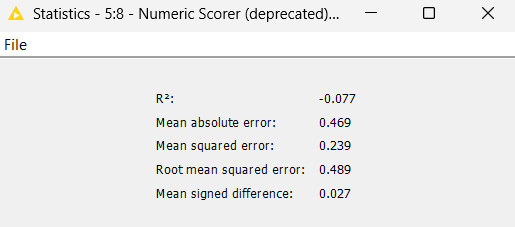

Berikut adalah visualisasi *Line Plot* untuk membandingkan fluktuasi nilai aktual dan hasil prediksi:

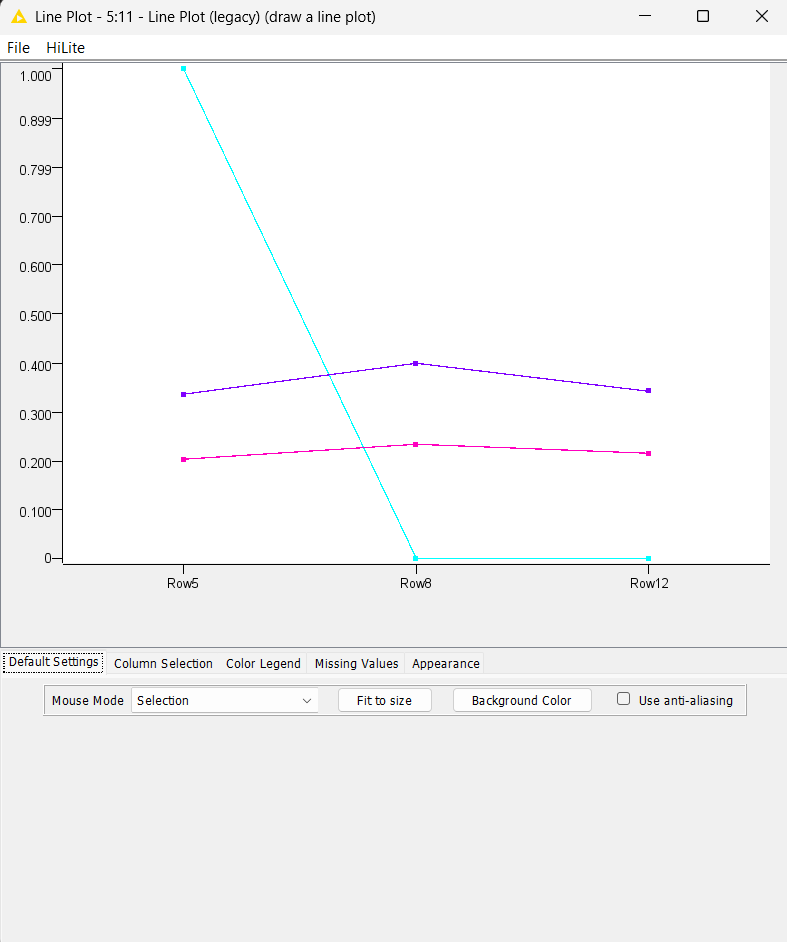

---

## 4. Simulasi Perhitungan Manual (Data Play Tennis)
Berdasarkan data 14 baris (D1-D14), saya menghitung **Gini Impurity** awal untuk data keseluruhan:

* Total data ($n$) = 14
* Jumlah "Yes" = 9, Jumlah "No" = 5
$$Gini(S) = 1 - (9/14)^2 - (5/14)^2 = \mathbf{0.460}$$

---

## 5. Analisis Hasil Akhir
Dalam tugas ini, terlihat bahwa akurasi pada data uji (**66.67%**) jauh lebih baik daripada akurasi OOB (**36.36%**). Hal ini dipengaruhi oleh keterbatasan jumlah sampel pada dataset, sehingga performa internal model (*OOB error*) masih cukup tinggi. Penggunaan **Normalisasi** tetap saya lakukan untuk menjaga konsistensi dan stabilitas perhitungan seperti pada tugas saya sebelumnya.